In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
import warnings

warnings.filterwarnings("ignore")
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/GiveMeSomeCredit/Data Dictionary.xls
/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv
/kaggle/input/competitions/GiveMeSomeCredit/sampleEntry.csv
/kaggle/input/competitions/GiveMeSomeCredit/cs-test.csv


In [2]:
!pip install scorecardpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60629 sha256=f0442914a2f08d216720483843298b399bbd1a62108b49ad53d97860fa26a108
  Stored in directory: /root/.cache/pip/wheels/9f/d8/4e/61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy


In [3]:
train_data = pd.read_csv("/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv", index_col=0)
test_data = pd.read_csv("/kaggle/input/competitions/GiveMeSomeCredit/cs-test.csv", index_col=0)

# Quy trình tiền xử lý chính
- Loại bỏ dữ liệu trùng lặp
- Chia tập dữ liệu train/valid (Chia stratified)
- Xử lý các giá trị bất thường
- WOE binning và chọn biến bằng Information Value
- Xử lý đa cộng tuyến bằng Variance Inflation Factor

# Chia dữ liệu

In [4]:
from sklearn.model_selection import train_test_split

# Loại bỏ trùng lặp
print(train_data.shape)
train_data = train_data.drop_duplicates()
print(train_data.shape)

# Chia tập train/valid
target = "SeriousDlqin2yrs"
X = train_data.drop(columns=[target])
y = train_data[target]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts(normalize=True))
print(y_valid.value_counts(normalize=True))

(150000, 11)
(149391, 11)
SeriousDlqin2yrs
0    0.933003
1    0.066997
Name: proportion, dtype: float64
SeriousDlqin2yrs
0    0.932996
1    0.067004
Name: proportion, dtype: float64


# Xử lý các giá trị bất thường, missing

- Xử lý các biến trễ nợ có giá trị 96, 98 bằng median
- Xử lý missing NumberOfDependents bằng median
- Xử lý biến age có giá trị = 0 bằng median

In [5]:
X_test = test_data.drop(columns=[target], errors="ignore").copy()

# Xử lý các biến trễ nợ có giá trị 96, 98 bằng median
delay_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]

for col in delay_cols:
    median_value = X_train.loc[~X_train[col].isin([96, 98]), col].median()
    X_train[col] = X_train[col].replace([96, 98], median_value)
    X_valid[col] = X_valid[col].replace([96, 98], median_value)
    X_test[col] = X_test[col].replace([96, 98], median_value)

# Xử lý missing NumberOfDependents bằng median
median_dependents = X_train["NumberOfDependents"].median()
X_train["NumberOfDependents"] = X_train["NumberOfDependents"].fillna(median_dependents)
X_valid["NumberOfDependents"] = X_valid["NumberOfDependents"].fillna(median_dependents)
X_test["NumberOfDependents"] = X_test["NumberOfDependents"].fillna(median_dependents)

# Xử lý biến age có giá trị = 0 bằng median
median_age = X_train.loc[X_train["age"] != 0, "age"].median()
X_train.loc[X_train["age"] == 0, "age"] = median_age
X_valid.loc[X_valid["age"] == 0, "age"] = median_age
X_test.loc[X_test["age"] == 0, "age"] = median_age

In [6]:
X_train.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
33185,0.628651,65,0,1827.000000,NaN,9,0,0,0,0.0
106384,0.011567,80,0,1.704319,300.0,10,0,0,0,0.0
13757,0.131268,79,0,0.343137,8363.0,5,0,2,0,0.0
72180,1.000000,27,0,0.189684,3605.0,5,0,0,0,0.0
53117,0.115464,67,0,0.360104,3062.0,15,0,1,0,0.0


# WOE Binning

[INFO] creating woe binning ...
Số biến ban đầu: 10
Số biến sau khi lọc (IV >= 0.02): 9
Danh sách các biến được giữ lại: ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberRealEstateLoansOrLines', 'NumberOfTimes90DaysLate', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...


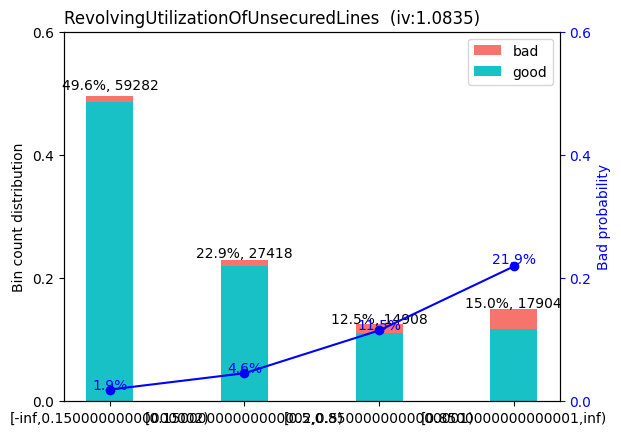

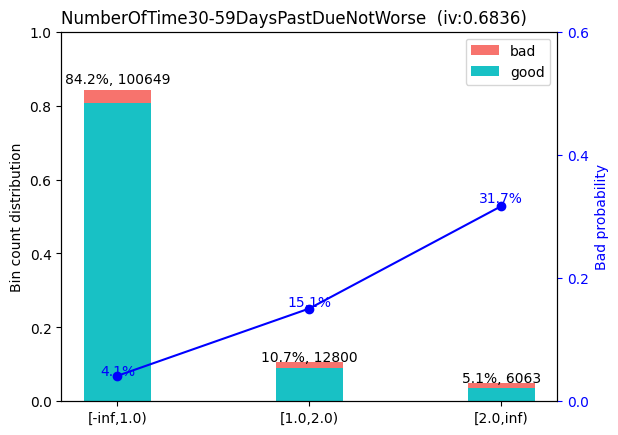

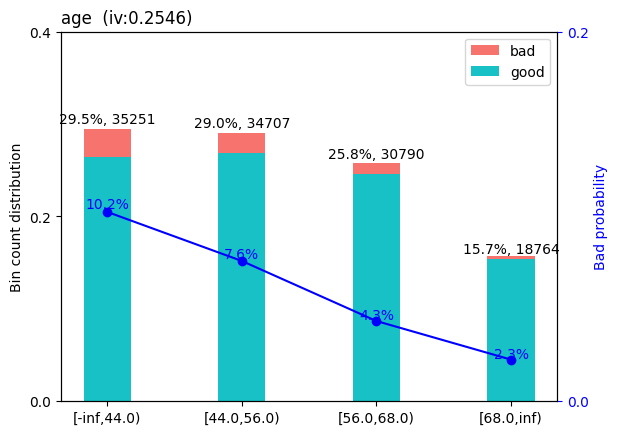

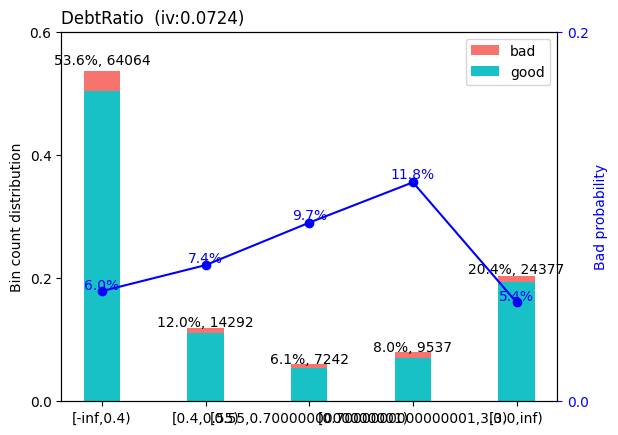

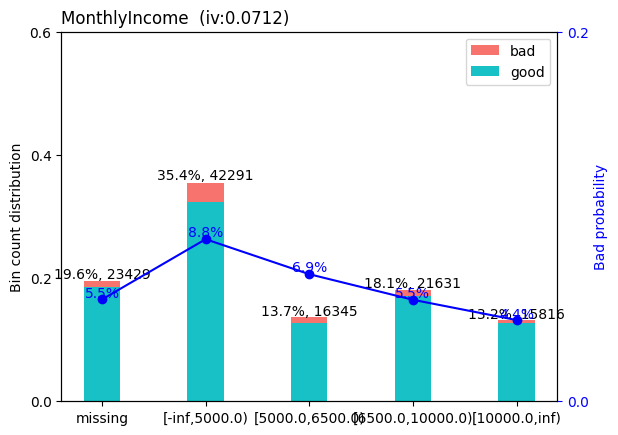

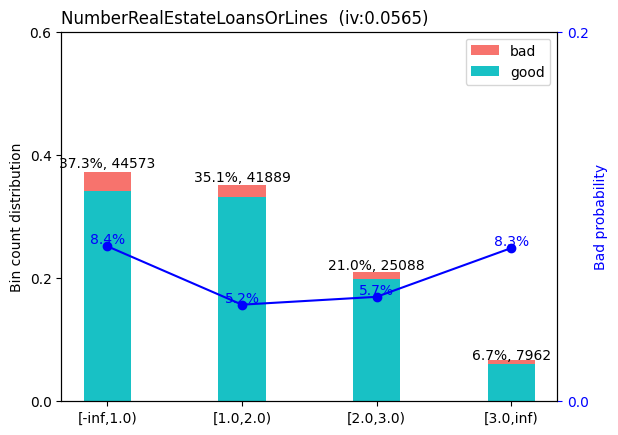

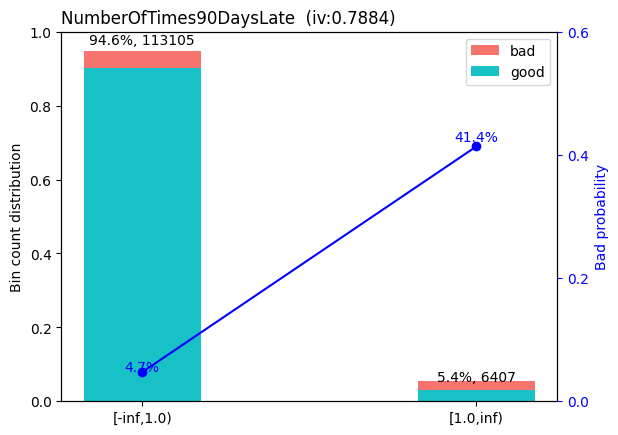

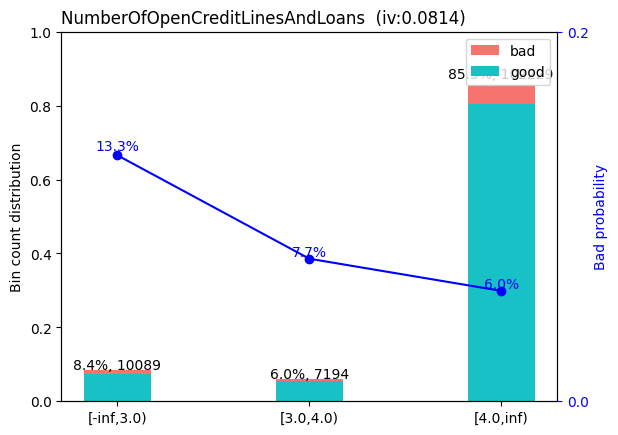

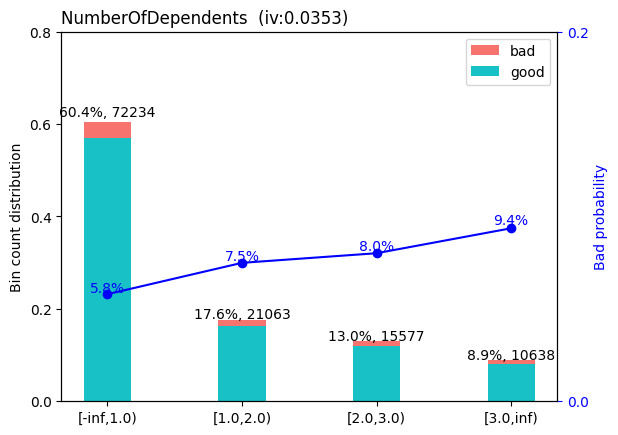

In [7]:
import scorecardpy as sc
import pandas as pd

train_woe_input = pd.concat([X_train, y_train], axis=1)

bins = sc.woebin(
    train_woe_input,
    y=target,
    bin_num_limit=5
)

iv_threshold = 0.02

filtered_bins = {
    var: df for var, df in bins.items()
    if df["total_iv"].iloc[0] >= iv_threshold
}

print(f"Số biến ban đầu: {len(bins)}")
print(f"Số biến sau khi lọc (IV >= {iv_threshold}): {len(filtered_bins)}")
print("Danh sách các biến được giữ lại:", list(filtered_bins.keys()))

sc.woebin_plot(filtered_bins)

X_train_woe = sc.woebin_ply(X_train, filtered_bins)
X_valid_woe = sc.woebin_ply(X_valid, filtered_bins)
X_test_woe = sc.woebin_ply(X_test, filtered_bins)

woe_cols = [c for c in X_train_woe.columns if c.endswith("_woe")]

X_train_woe = X_train_woe[woe_cols]
X_valid_woe = X_valid_woe[woe_cols]
X_test_woe = X_test_woe[woe_cols]

# Xử lý đa cộng tuyến 
### Ta sẽ loại bỏ dần các biến có VIF > 5 cho đến khi không còn biến nào vượt ngưỡng

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd
import numpy as np

def calculate_vif(df):
    X = df.copy().replace([np.inf, -np.inf], np.nan).dropna()
    X_const = sm.add_constant(X)
    
    vif_data = pd.DataFrame()
    vif_data["variable"] = X_const.columns
    
    vif_data["vif"] = [
        variance_inflation_factor(X_const.values, i)
        for i in range(X_const.shape[1])
    ]
    
    vif_data = vif_data[vif_data["variable"] != "const"]
    
    return vif_data.sort_values("vif", ascending=False).reset_index(drop=True)

def remove_high_vif(X_train, threshold=5.0):
    X_current = X_train.copy()
    removed_features = []

    while True:
        vif_df = calculate_vif(X_current)

        max_vif = vif_df["vif"].max()
        if max_vif <= threshold:
            break

        feature_to_drop = vif_df.iloc[0]["variable"]
        removed_features.append((feature_to_drop, max_vif))
        X_current = X_current.drop(columns=[feature_to_drop])

    return X_current, removed_features, calculate_vif(X_current)

X_train_woe, removed_features, vif_df = remove_high_vif(X_train_woe, threshold=5.0)

X_valid_woe = X_valid_woe[X_train_woe.columns]
X_test_woe = X_test_woe[X_train_woe.columns]

print("Các biến đã bị loại do VIF:")
print(removed_features)

print("VIF cuối cùng:")
print(vif_df)

Các biến đã bị loại do VIF:
[]
VIF cuối cùng:
                                   variable       vif
0  RevolvingUtilizationOfUnsecuredLines_woe  1.276125
1       NumberOfOpenCreditLinesAndLoans_woe  1.220062
2                             DebtRatio_woe  1.194069
3                                   age_woe  1.161604
4                         MonthlyIncome_woe  1.160253
5          NumberRealEstateLoansOrLines_woe  1.145414
6               NumberOfTimes90DaysLate_woe  1.138183
7                    NumberOfDependents_woe  1.133250
8  NumberOfTime30-59DaysPastDueNotWorse_woe  1.131505


In [9]:
target = "SeriousDlqin2yrs"

train_woe_export = pd.concat(
    [
        X_train_woe.reset_index(drop=True),
        y_train.reset_index(drop=True).rename(target)
    ],
    axis=1
)

valid_woe_export = pd.concat(
    [
        X_valid_woe.reset_index(drop=True),
        y_valid.reset_index(drop=True).rename(target)
    ],
    axis=1
)

if target in test_data.columns:
    test_woe_export = pd.concat(
        [
            X_test_woe.reset_index(drop=True),
            test_data[target].reset_index(drop=True).rename(target)
        ],
        axis=1
    )
else:
    test_woe_export = X_test_woe.reset_index(drop=True)

train_woe_export.to_csv("/kaggle/working/train_woe.csv", index=False)
valid_woe_export.to_csv("/kaggle/working/valid_woe.csv", index=False)
test_woe_export.to_csv("/kaggle/working/test_woe.csv", index=False)

print(train_woe_export.shape)
print(valid_woe_export.shape)
print(test_woe_export.shape)

(119512, 10)
(29879, 10)
(101503, 10)
